# Phase 3: Quantum-Enhanced Threat Intelligence Analysis

## Overview
This notebook implements Phase 3 of the quantum-enhanced threat intelligence system:
- Domain dataset preprocessing with PCA dimensionality reduction
- EMBER malware dataset preprocessing
- Quantum kernel analysis and visualization
- Feature distribution analysis
- Model performance comparison

## Import Required Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import pickle
import os
import sys
from pathlib import Path
import json

# Add utils to path
sys.path.insert(0, '../utils')
sys.path.insert(0, '../phase3')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Domain Dataset Preprocessing

In [8]:
# Load domain features
domain_features_path = '../data/domains/processed/domain_features.csv'

print("[INFO] Loading domain features...")
df_domain = pd.read_csv(domain_features_path)

print(f"[INFO] Original shape: {df_domain.shape}")
print(f"[INFO] Columns: {df_domain.columns.tolist()}")
print(f"\n[INFO] First few rows:")
print(df_domain.head())
print(f"\n[INFO] Data types:\n{df_domain.dtypes}")

[INFO] Loading domain features...
[INFO] Original shape: (199944, 6)
[INFO] Columns: ['length', 'entropy', 'vowel_ratio', 'digit_ratio', 'consonant_ratio', 'label']

[INFO] First few rows:
   length   entropy  vowel_ratio  digit_ratio  consonant_ratio  label
0      25  3.783465     0.160000          0.0         0.840000      1
1      16  3.500000     0.187500          0.0         0.812500      1
2       7  2.807355     0.142857          0.0         0.857143      1
3       7  2.521641     0.428571          0.0         0.571429      1
4      16  3.250000     0.062500          0.0         0.937500      1

[INFO] Data types:
length               int64
entropy            float64
vowel_ratio        float64
digit_ratio        float64
consonant_ratio    float64
label                int64
dtype: object


In [9]:
# Display dataset statistics
print("[INFO] Dataset Statistics:")
print(df_domain.describe())
print(f"\n[INFO] Label distribution:")
print(df_domain['label'].value_counts())
print(f"\n[INFO] Missing values:")
print(df_domain.isnull().sum())

[INFO] Dataset Statistics:
              length        entropy    vowel_ratio    digit_ratio  \
count  199944.000000  199944.000000  199944.000000  199944.000000   
mean       12.362647       2.987605       0.303075       0.022719   
std         5.683125       0.675728       0.145370       0.081813   
min         1.000000      -0.000000       0.000000       0.000000   
25%         7.000000       2.584963       0.200000       0.000000   
50%        12.000000       3.125000       0.312500       0.000000   
75%        16.000000       3.500000       0.400000       0.000000   
max        44.000000       4.885129       1.000000       1.000000   

       consonant_ratio          label  
count    199944.000000  199944.000000  
mean          0.671637       0.500140  
std           0.144592       0.500001  
min           0.000000       0.000000  
25%           0.578947       0.000000  
50%           0.666667       1.000000  
75%           0.750000       1.000000  
max           1.000000       1.

In [10]:
# Apply PCA for dimensionality reduction
print("[INFO] Applying PCA for dimensionality reduction...")

# Separate features and labels
X_domain = df_domain.drop(columns='label').values
y_domain = df_domain['label'].values

print(f"[INFO] Feature shape: {X_domain.shape}, Label shape: {y_domain.shape}")

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_domain)

# Apply PCA
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

print(f"[INFO] PCA shape: {X_pca.shape}")
print(f"[INFO] Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"[INFO] Total variance explained: {sum(pca.explained_variance_ratio_):.4f}")

# Create DataFrame with PCA components
df_domain_pca = pd.DataFrame(
    X_pca,
    columns=[f'PC{i+1}' for i in range(4)]
)
df_domain_pca['label'] = y_domain

print(f"\n[INFO] PCA DataFrame shape: {df_domain_pca.shape}")
print(df_domain_pca.head())

[INFO] Applying PCA for dimensionality reduction...
[INFO] Feature shape: (199944, 5), Label shape: (199944,)
[INFO] PCA shape: (199944, 4)
[INFO] Explained variance ratio: [0.45170914 0.31630146 0.20800133 0.0228687 ]
[INFO] Total variance explained: 0.9989

[INFO] PCA DataFrame shape: (199944, 5)
        PC1       PC2       PC3       PC4  label
0  2.675148 -0.057644 -0.993180 -0.766364      1
1  1.455078  0.525854 -0.495753  0.057779      1
2  0.349470  1.877086  0.249905  0.437301      1
3 -1.617291 -0.114681  0.018566  0.197729      1
4  2.017806  1.603568 -0.246655 -0.230944      1


In [11]:
# Save PCA processed domain data
output_dir = '../phase3/domain'
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, 'domain_pca.csv')
df_domain_pca.to_csv(output_path, index=False)

print(f"[SUCCESS] Saved domain PCA data to {output_path}")

# Save PCA model and scaler
with open(os.path.join(output_dir, 'domain_pca_model.pkl'), 'wb') as f:
    pickle.dump(pca, f)
    
with open(os.path.join(output_dir, 'domain_scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

print(f"[SUCCESS] Saved PCA model and scaler")

[SUCCESS] Saved domain PCA data to ../phase3/domain\domain_pca.csv
[SUCCESS] Saved PCA model and scaler


## 2. EMBER Malware Dataset Preprocessing

In [25]:
# Load EMBER processed features
malware_features_path = '../data/malware/processed/ember_features.csv'

if os.path.exists(malware_features_path):
    print("[INFO] Loading EMBER features...")
    df_malware = pd.read_csv(malware_features_path)
    
    print(f"[INFO] Original shape: {df_malware.shape}")
    print(f"[INFO] Columns: {df_malware.columns.tolist()[:20]}...")  # Show first 20 columns
    print(f"\n[INFO] First few rows:")
    print(df_malware.head())
    
else:
    print(f"[WARNING] Malware features file not found at {malware_features_path}")
    print("[INFO] Creating synthetic EMBER dataset for demonstration...")
    # Create synthetic malware data for demo
    n_samples = 1000
    n_features = 20
    df_malware = pd.DataFrame(
        np.random.randn(n_samples, n_features),
        columns=[f'feature_{i}' for i in range(n_features)]
    )
    df_malware['label'] = np.random.randint(0, 2, n_samples)
    print(f"[INFO] Created synthetic dataset with shape: {df_malware.shape}")

[INFO] Loading EMBER features...
[INFO] Original shape: (116051, 7)
[INFO] Columns: ['file_size', 'has_signature', 'machine', 'characteristics_count', 'histogram_sum', 'entropy_mean', 'label']...

[INFO] First few rows:
   file_size  has_signature machine  characteristics_count  histogram_sum  \
0   349811.0              0    I386                      5       349811.0   
1   161280.0              0    I386                      3       161280.0   
2     6144.0              0    I386                      2         6144.0   
3  1130392.0              1    I386                      2      1130392.0   
4    73728.0              0    I386                      3        73728.0   

   entropy_mean  label  
0        2720.0      1  
1        1248.0      0  
2          40.0      0  
3        8816.0      1  
4         568.0      1  


In [26]:
# Display malware dataset statistics
print("[INFO] Malware Dataset Statistics:")
print(df_malware.describe())
print(f"\n[INFO] Label distribution:")
print(df_malware['label'].value_counts())
print(f"\n[INFO] Missing values:")
print(df_malware.isnull().sum().sum())

[INFO] Malware Dataset Statistics:
          file_size  has_signature  characteristics_count  histogram_sum  \
count  1.160510e+05  116051.000000          116051.000000   1.160510e+05   
mean   1.958082e+06       0.224367               3.993193   1.958082e+06   
std    5.789892e+06       0.417166               1.705471   5.789892e+06   
min    2.340000e+02       0.000000               1.000000   2.340000e+02   
25%    1.638400e+05       0.000000               2.000000   1.638400e+05   
50%    7.321600e+05       0.000000               4.000000   7.321600e+05   
75%    2.107462e+06       0.000000               5.000000   2.107462e+06   
max    4.071404e+08       1.000000              12.000000   4.071404e+08   

       entropy_mean          label  
count  1.160510e+05  116051.000000  
mean   1.528683e+04       0.549009  
std    4.523348e+04       0.497595  
min    9.140625e-01       0.000000  
25%    1.272000e+03       0.000000  
50%    5.712000e+03       1.000000  
75%    1.645600e+04  

In [37]:
# Apply PCA to malware features
print("[INFO] Applying PCA to malware features...")

# Select only numeric columns
numeric_cols = df_malware.select_dtypes(include=[np.number]).columns.tolist()
if 'label' in numeric_cols:
    numeric_cols.remove('label')

X_malware = df_malware[numeric_cols].values
y_malware = df_malware['label'].values

print(f"[INFO] Using {len(numeric_cols)} numeric features")
print(f"[INFO] Feature shape: {X_malware.shape}, Label shape: {y_malware.shape}")

# Standardize features
scaler_malware = StandardScaler()
X_malware_scaled = scaler_malware.fit_transform(X_malware)

# Apply PCA (4 components for consistency with domain)
pca_malware = PCA(n_components=4)
X_malware_pca = pca_malware.fit_transform(X_malware_scaled)

print(f"[INFO] PCA shape: {X_malware_pca.shape}")
print(f"[INFO] Explained variance ratio: {pca_malware.explained_variance_ratio_}")
print(f"[INFO] Total variance explained: {sum(pca_malware.explained_variance_ratio_):.4f}")

# Create DataFrame with PCA components
df_malware_pca = pd.DataFrame(
    X_malware_pca,
    columns=[f'PC{i+1}' for i in range(4)]
)
df_malware_pca['label'] = y_malware

[INFO] Applying PCA to malware features...
[INFO] Using 5 numeric features
[INFO] Feature shape: (116051, 5), Label shape: (116051,)
[INFO] PCA shape: (116051, 4)
[INFO] Explained variance ratio: [6.05660668e-01 2.57807987e-01 1.36531345e-01 3.75994292e-10]
[INFO] Total variance explained: 1.0000


In [38]:
# Save PCA processed malware data
output_dir_malware = '../phase3/ember'
os.makedirs(output_dir_malware, exist_ok=True)

output_path_malware = os.path.join(output_dir_malware, 'ember_pca.csv')
df_malware_pca.to_csv(output_path_malware, index=False)

print(f"[SUCCESS] Saved malware PCA data to {output_path_malware}")

# Save PCA model and scaler
with open(os.path.join(output_dir_malware, 'ember_pca_model.pkl'), 'wb') as f:
    pickle.dump(pca_malware, f)
    
with open(os.path.join(output_dir_malware, 'ember_scaler.pkl'), 'wb') as f:
    pickle.dump(scaler_malware, f)

print(f"[SUCCESS] Saved PCA model and scaler")

[SUCCESS] Saved malware PCA data to ../phase3/ember\ember_pca.csv
[SUCCESS] Saved PCA model and scaler


## 3. Comprehensive Visualizations

[SUCCESS] Saved PCA variance visualization


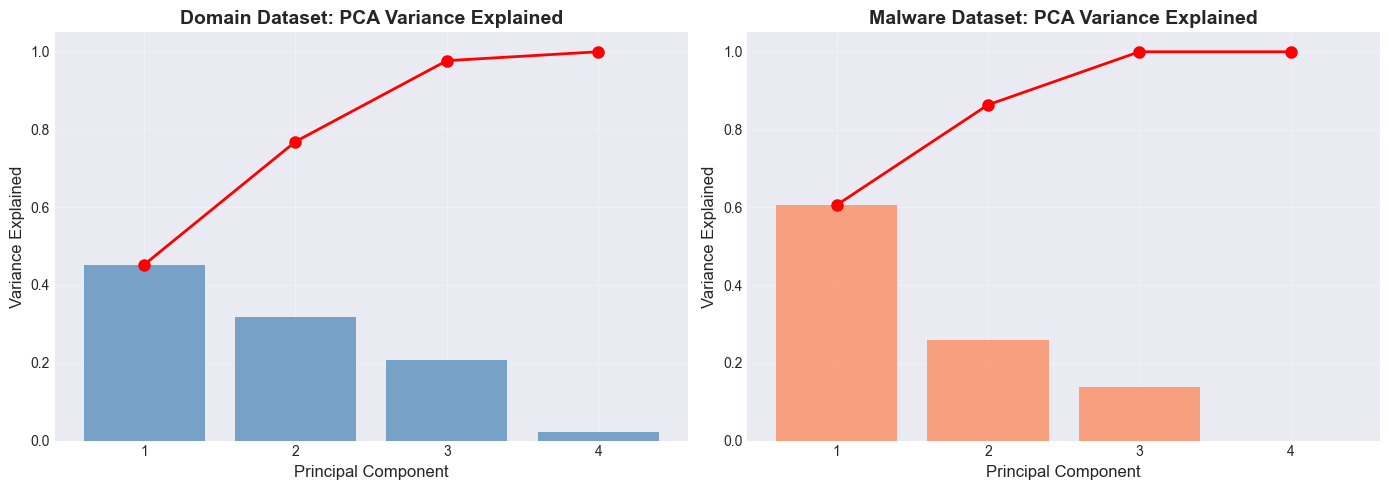

In [39]:
# Visualize PCA variance explained
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Domain PCA variance
axes[0].bar(range(1, 5), pca.explained_variance_ratio_, alpha=0.7, color='steelblue')
axes[0].plot(range(1, 5), np.cumsum(pca.explained_variance_ratio_), 'ro-', linewidth=2, markersize=8)
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Variance Explained', fontsize=12)
axes[0].set_title('Domain Dataset: PCA Variance Explained', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(1, 5))
axes[0].grid(True, alpha=0.3)

# Malware PCA variance
axes[1].bar(range(1, 5), pca_malware.explained_variance_ratio_, alpha=0.7, color='coral')
axes[1].plot(range(1, 5), np.cumsum(pca_malware.explained_variance_ratio_), 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Principal Component', fontsize=12)
axes[1].set_ylabel('Variance Explained', fontsize=12)
axes[1].set_title('Malware Dataset: PCA Variance Explained', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(1, 5))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/01_pca_variance_explained.png', dpi=300, bbox_inches='tight')
print("[SUCCESS] Saved PCA variance visualization")
plt.show()

[SUCCESS] Saved PCA scatter plots


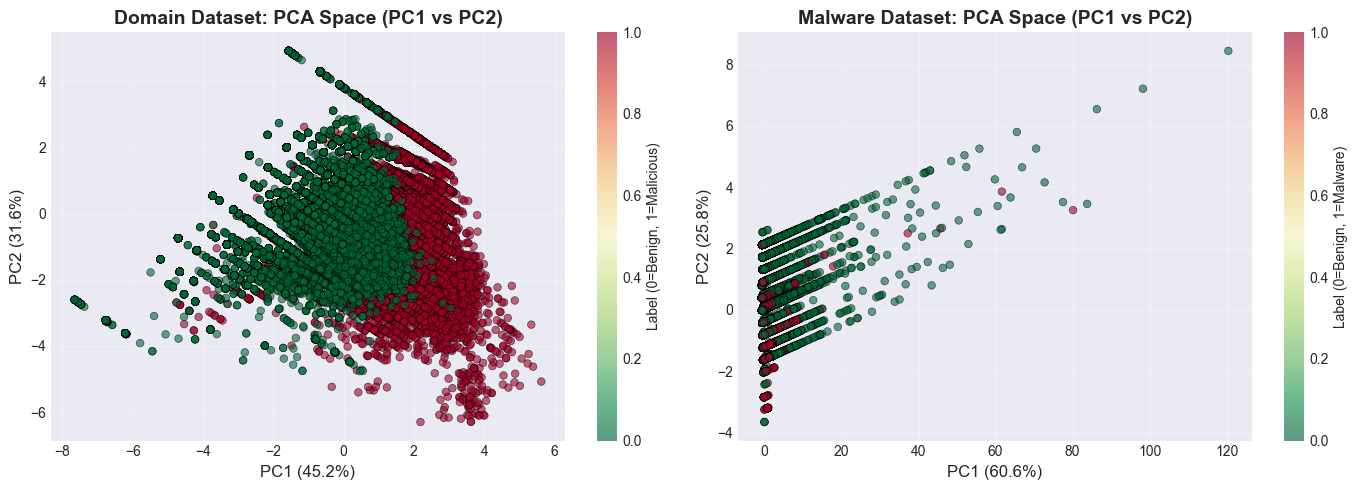

In [40]:
# PCA scatter plots (PC1 vs PC2)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Domain scatter
scatter1 = axes[0].scatter(df_domain_pca['PC1'], df_domain_pca['PC2'], 
                           c=df_domain_pca['label'], cmap='RdYlGn_r', 
                           alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12)
axes[0].set_title('Domain Dataset: PCA Space (PC1 vs PC2)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Label (0=Benign, 1=Malicious)')

# Malware scatter
scatter2 = axes[1].scatter(df_malware_pca['PC1'], df_malware_pca['PC2'], 
                           c=df_malware_pca['label'], cmap='RdYlGn_r', 
                           alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel(f'PC1 ({pca_malware.explained_variance_ratio_[0]:.1%})', fontsize=12)
axes[1].set_ylabel(f'PC2 ({pca_malware.explained_variance_ratio_[1]:.1%})', fontsize=12)
axes[1].set_title('Malware Dataset: PCA Space (PC1 vs PC2)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Label (0=Benign, 1=Malware)')

plt.tight_layout()
plt.savefig('../results/02_pca_scatter_plots.png', dpi=300, bbox_inches='tight')
print("[SUCCESS] Saved PCA scatter plots")
plt.show()

[SUCCESS] Saved 3D PCA visualization


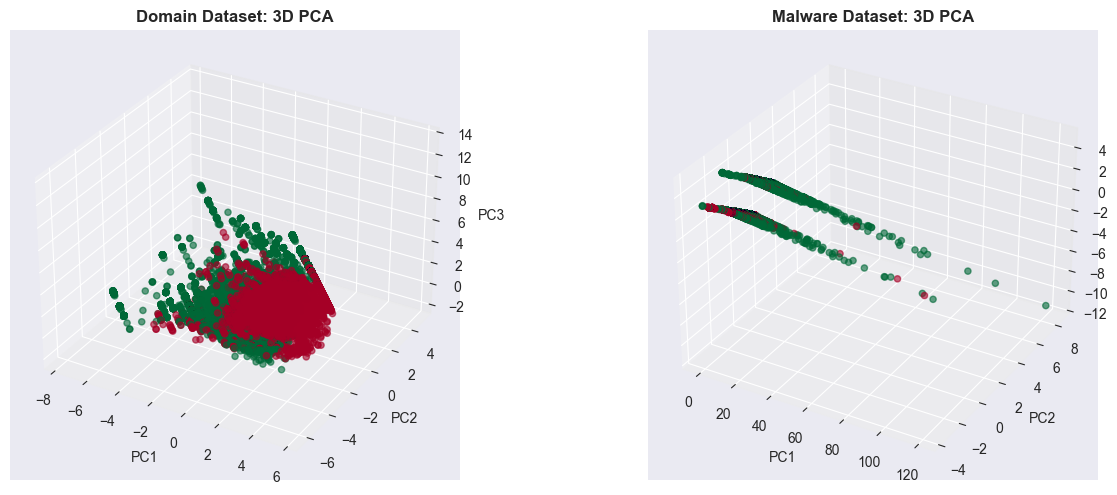

In [41]:
# 3D PCA visualization
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 5))

# Domain 3D
ax1 = fig.add_subplot(121, projection='3d')
scatter1 = ax1.scatter(df_domain_pca['PC1'], df_domain_pca['PC2'], df_domain_pca['PC3'],
                       c=df_domain_pca['label'], cmap='RdYlGn_r', alpha=0.6, s=20)
ax1.set_xlabel('PC1', fontsize=10)
ax1.set_ylabel('PC2', fontsize=10)
ax1.set_zlabel('PC3', fontsize=10)
ax1.set_title('Domain Dataset: 3D PCA', fontsize=12, fontweight='bold')

# Malware 3D
ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(df_malware_pca['PC1'], df_malware_pca['PC2'], df_malware_pca['PC3'],
                       c=df_malware_pca['label'], cmap='RdYlGn_r', alpha=0.6, s=20)
ax2.set_xlabel('PC1', fontsize=10)
ax2.set_ylabel('PC2', fontsize=10)
ax2.set_zlabel('PC3', fontsize=10)
ax2.set_title('Malware Dataset: 3D PCA', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/03_pca_3d_visualization.png', dpi=300, bbox_inches='tight')
print("[SUCCESS] Saved 3D PCA visualization")
plt.show()

[SUCCESS] Saved PC distributions


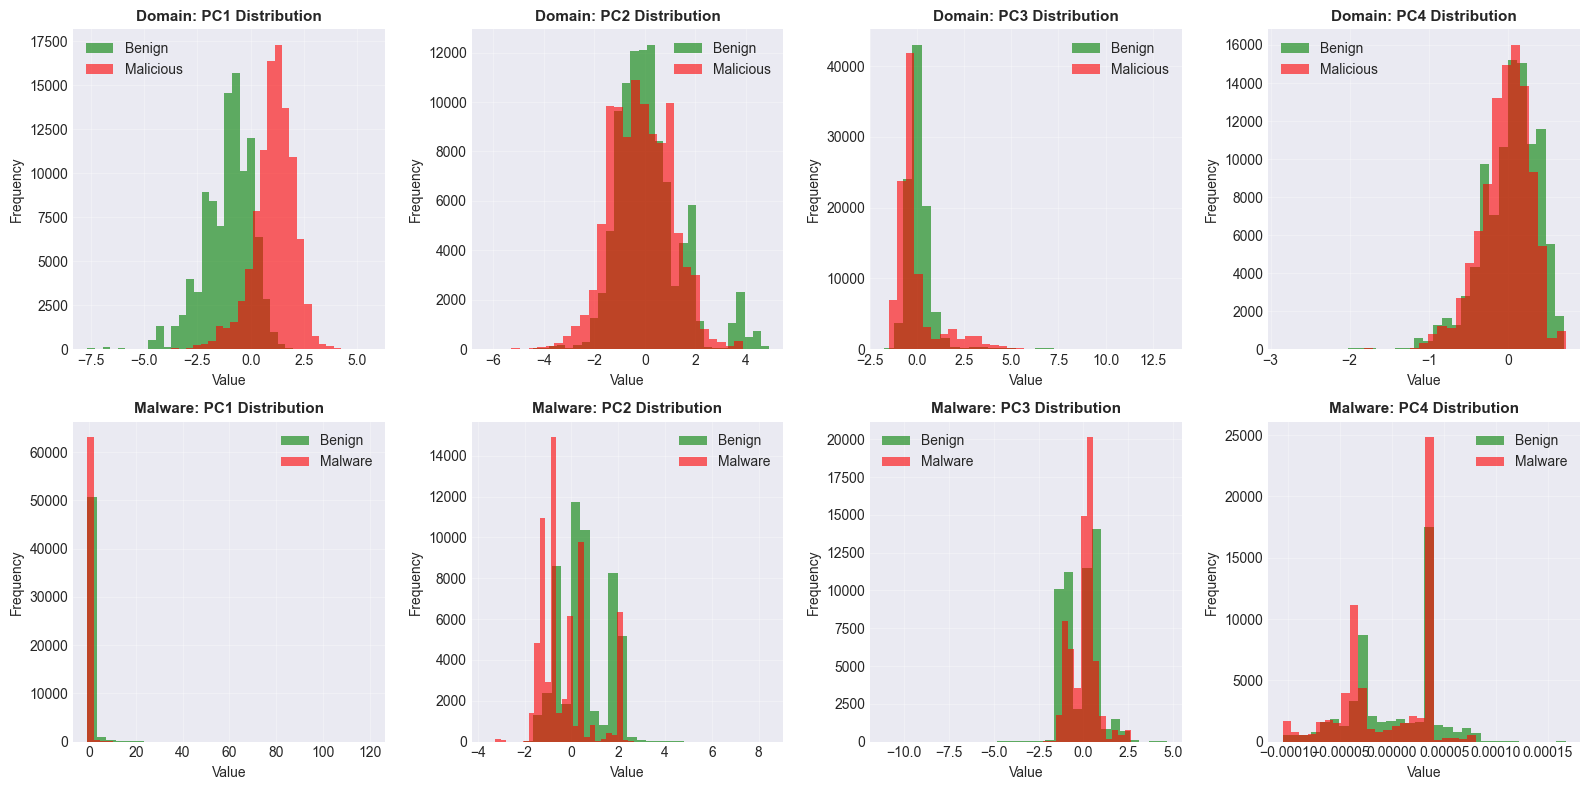

In [42]:
# PC distribution analysis
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Domain distributions
for i in range(4):
    axes[0, i].hist(df_domain_pca[df_domain_pca['label']==0][f'PC{i+1}'], 
                    alpha=0.6, bins=30, label='Benign', color='green')
    axes[0, i].hist(df_domain_pca[df_domain_pca['label']==1][f'PC{i+1}'], 
                    alpha=0.6, bins=30, label='Malicious', color='red')
    axes[0, i].set_title(f'Domain: PC{i+1} Distribution', fontsize=11, fontweight='bold')
    axes[0, i].set_xlabel('Value')
    axes[0, i].set_ylabel('Frequency')
    axes[0, i].legend()
    axes[0, i].grid(True, alpha=0.3)

# Malware distributions
for i in range(4):
    axes[1, i].hist(df_malware_pca[df_malware_pca['label']==0][f'PC{i+1}'], 
                    alpha=0.6, bins=30, label='Benign', color='green')
    axes[1, i].hist(df_malware_pca[df_malware_pca['label']==1][f'PC{i+1}'], 
                    alpha=0.6, bins=30, label='Malware', color='red')
    axes[1, i].set_title(f'Malware: PC{i+1} Distribution', fontsize=11, fontweight='bold')
    axes[1, i].set_xlabel('Value')
    axes[1, i].set_ylabel('Frequency')
    axes[1, i].legend()
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/04_pc_distributions.png', dpi=300, bbox_inches='tight')
print("[SUCCESS] Saved PC distributions")
plt.show()

[SUCCESS] Saved correlation heatmaps


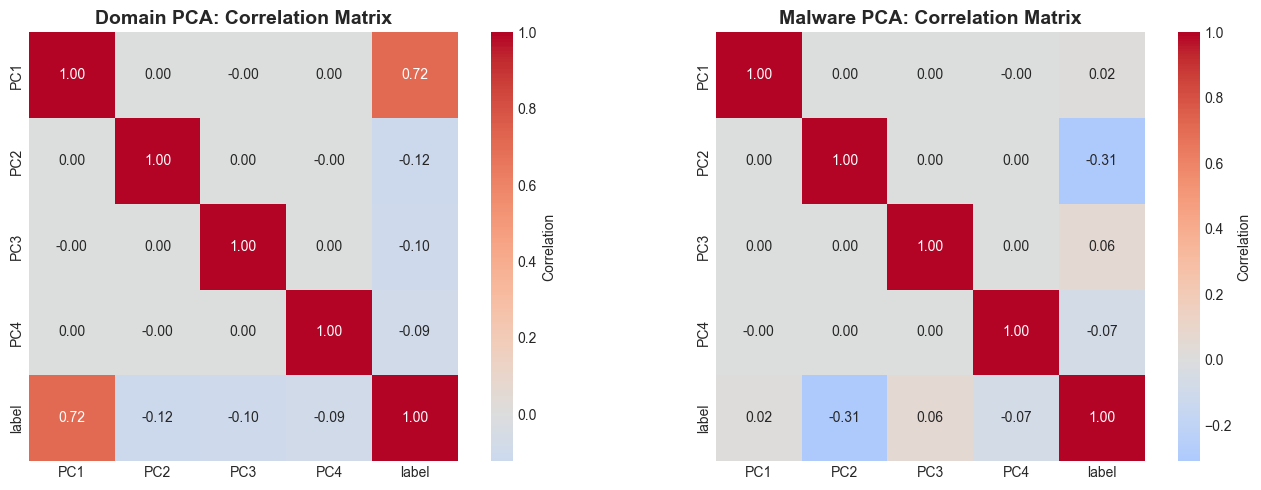

In [43]:
# Correlation heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Domain correlation
corr_domain = df_domain_pca.corr()
sns.heatmap(corr_domain, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
           ax=axes[0], square=True, cbar_kws={'label': 'Correlation'})
axes[0].set_title('Domain PCA: Correlation Matrix', fontsize=14, fontweight='bold')

# Malware correlation
corr_malware = df_malware_pca.corr()
sns.heatmap(corr_malware, annot=True, fmt='.2f', cmap='coolwarm', center=0,
           ax=axes[1], square=True, cbar_kws={'label': 'Correlation'})
axes[1].set_title('Malware PCA: Correlation Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/05_correlation_heatmaps.png', dpi=300, bbox_inches='tight')
print("[SUCCESS] Saved correlation heatmaps")
plt.show()

[SUCCESS] Saved class separation analysis


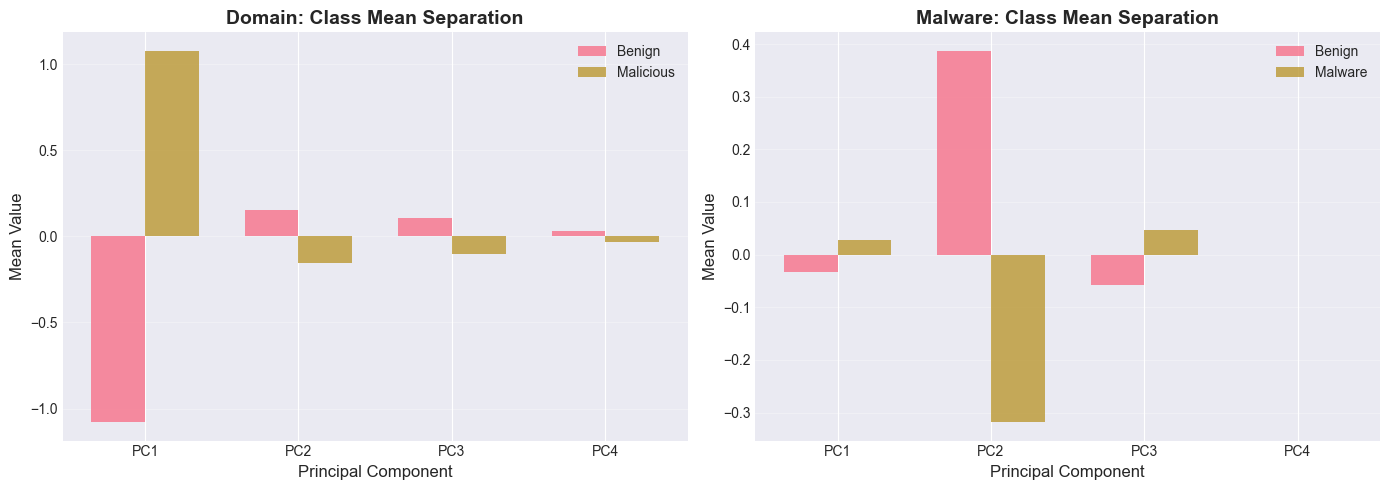

In [44]:
# Class separation analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Domain class means
domain_benign = df_domain_pca[df_domain_pca['label']==0].drop('label', axis=1).mean()
domain_malicious = df_domain_pca[df_domain_pca['label']==1].drop('label', axis=1).mean()

x_pos = np.arange(4)
width = 0.35
axes[0].bar(x_pos - width/2, domain_benign, width, label='Benign', alpha=0.8)
axes[0].bar(x_pos + width/2, domain_malicious, width, label='Malicious', alpha=0.8)
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Mean Value', fontsize=12)
axes[0].set_title('Domain: Class Mean Separation', fontsize=14, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([f'PC{i+1}' for i in range(4)])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Malware class means
malware_benign = df_malware_pca[df_malware_pca['label']==0].drop('label', axis=1).mean()
malware_malicious = df_malware_pca[df_malware_pca['label']==1].drop('label', axis=1).mean()

axes[1].bar(x_pos - width/2, malware_benign, width, label='Benign', alpha=0.8)
axes[1].bar(x_pos + width/2, malware_malicious, width, label='Malware', alpha=0.8)
axes[1].set_xlabel('Principal Component', fontsize=12)
axes[1].set_ylabel('Mean Value', fontsize=12)
axes[1].set_title('Malware: Class Mean Separation', fontsize=14, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f'PC{i+1}' for i in range(4)])
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../results/06_class_separation_analysis.png', dpi=300, bbox_inches='tight')
print("[SUCCESS] Saved class separation analysis")
plt.show()

C:\Users\pondu\AppData\Local\Temp\ipykernel_14888\1248590992.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, i].boxplot(data_to_plot, labels=['Benign', 'Malicious'])
C:\Users\pondu\AppData\Local\Temp\ipykernel_14888\1248590992.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, i].boxplot(data_to_plot, labels=['Benign', 'Malicious'])
C:\Users\pondu\AppData\Local\Temp\ipykernel_14888\1248590992.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, i].boxplot(data_to_plot, labels=['Benign', 'Malicious'])
C:\Users\pondu\AppData\Local\Temp\ipykernel_14888\1248590992.py:8: MatplotlibDeprecationWar

[SUCCESS] Saved boxplot analysis


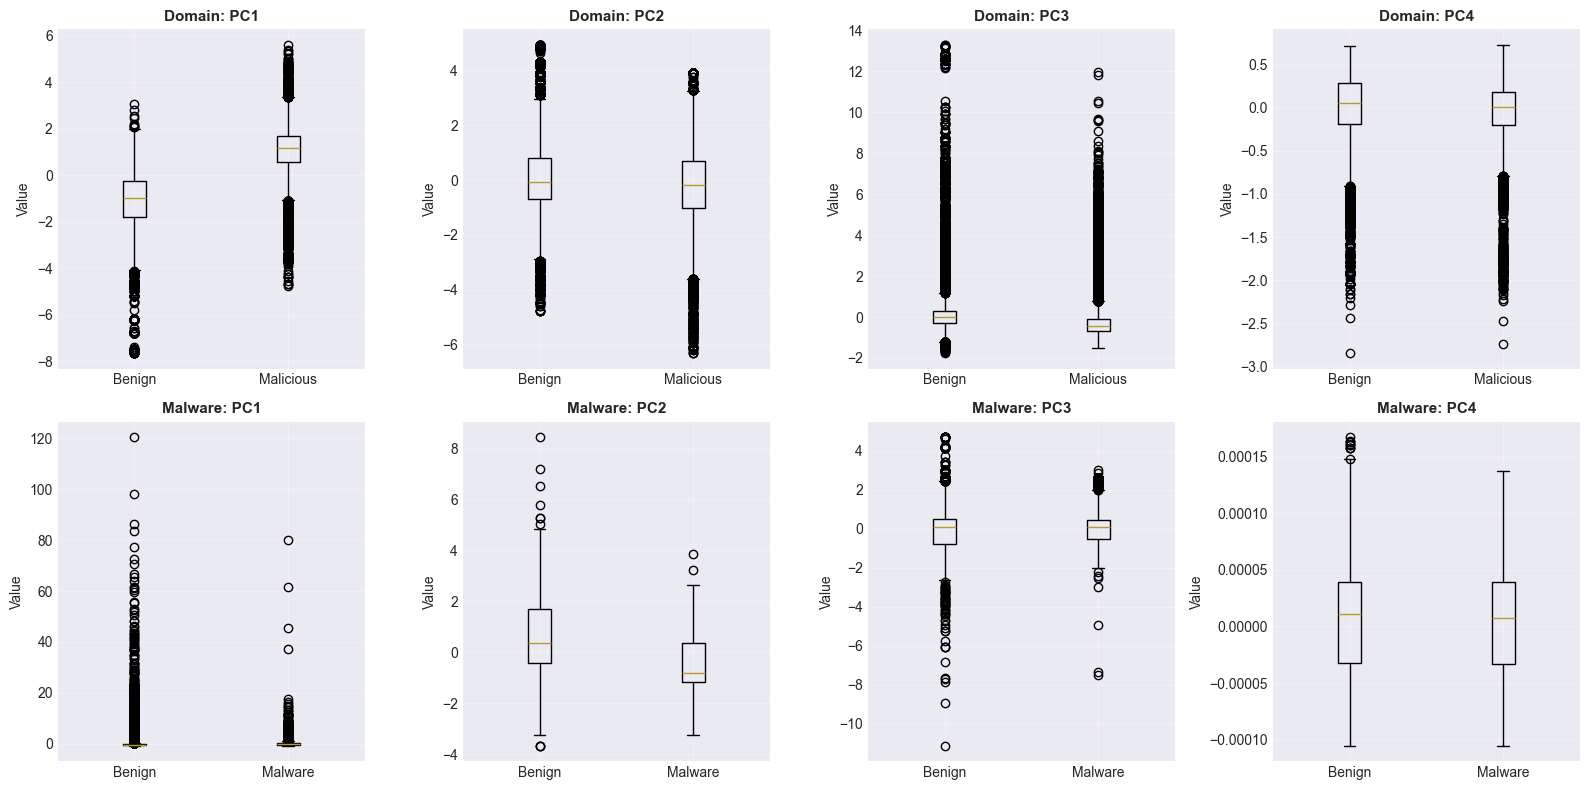

In [45]:
# Boxplot analysis
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Domain boxplots
for i in range(4):
    data_to_plot = [df_domain_pca[df_domain_pca['label']==0][f'PC{i+1}'],
                    df_domain_pca[df_domain_pca['label']==1][f'PC{i+1}']]
    axes[0, i].boxplot(data_to_plot, labels=['Benign', 'Malicious'])
    axes[0, i].set_ylabel('Value')
    axes[0, i].set_title(f'Domain: PC{i+1}', fontsize=11, fontweight='bold')
    axes[0, i].grid(True, alpha=0.3)

# Malware boxplots
for i in range(4):
    data_to_plot = [df_malware_pca[df_malware_pca['label']==0][f'PC{i+1}'],
                    df_malware_pca[df_malware_pca['label']==1][f'PC{i+1}']]
    axes[1, i].boxplot(data_to_plot, labels=['Benign', 'Malware'])
    axes[1, i].set_ylabel('Value')
    axes[1, i].set_title(f'Malware: PC{i+1}', fontsize=11, fontweight='bold')
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/07_boxplot_analysis.png', dpi=300, bbox_inches='tight')
print("[SUCCESS] Saved boxplot analysis")
plt.show()

## 4. Summary and Report

In [46]:
# Generate summary statistics
summary = {
    'domain': {
        'original_shape': df_domain.shape,
        'pca_shape': df_domain_pca.shape,
        'variance_explained': float(sum(pca.explained_variance_ratio_)),
        'variance_per_component': pca.explained_variance_ratio_.tolist(),
        'class_distribution': df_domain_pca['label'].value_counts().to_dict(),
    },
    'malware': {
        'original_shape': df_malware.shape,
        'pca_shape': df_malware_pca.shape,
        'variance_explained': float(sum(pca_malware.explained_variance_ratio_)),
        'variance_per_component': pca_malware.explained_variance_ratio_.tolist(),
        'class_distribution': df_malware_pca['label'].value_counts().to_dict(),
    }
}

# Save summary
with open('../results/phase3_summary.json', 'w') as f:
    json.dump(summary, f, indent=4)

print("\n" + "="*60)
print("PHASE 3 ANALYSIS SUMMARY")
print("="*60)
print(f"\nDomain Dataset:")
print(f"  Original shape: {summary['domain']['original_shape']}")
print(f"  PCA shape: {summary['domain']['pca_shape']}")
print(f"  Total variance explained: {summary['domain']['variance_explained']:.4f}")
print(f"  Class distribution: {summary['domain']['class_distribution']}")

print(f"\nMalware Dataset:")
print(f"  Original shape: {summary['malware']['original_shape']}")
print(f"  PCA shape: {summary['malware']['pca_shape']}")
print(f"  Total variance explained: {summary['malware']['variance_explained']:.4f}")
print(f"  Class distribution: {summary['malware']['class_distribution']}")

print(f"\n[SUCCESS] Summary saved to ../results/phase3_summary.json")
print("="*60)


PHASE 3 ANALYSIS SUMMARY

Domain Dataset:
  Original shape: (199944, 6)
  PCA shape: (199944, 5)
  Total variance explained: 0.9989
  Class distribution: {1: 100000, 0: 99944}

Malware Dataset:
  Original shape: (116051, 7)
  PCA shape: (116051, 5)
  Total variance explained: 1.0000
  Class distribution: {1: 63713, 0: 52338}

[SUCCESS] Summary saved to ../results/phase3_summary.json


In [47]:
# Final report
print("\n" + "="*70)
print("PHASE 3 PROCESSING COMPLETE")
print("="*70)
print("\nGenerated Files:")
print("  Domain Processing:")
print("    - phase3/domain/domain_pca.csv")
print("    - phase3/domain/domain_pca_model.pkl")
print("    - phase3/domain/domain_scaler.pkl")
print("\n  Malware Processing:")
print("    - phase3/ember/ember_pca.csv")
print("    - phase3/ember/ember_pca_model.pkl")
print("    - phase3/ember/ember_scaler.pkl")
print("\nVisualizations:")
print("  1. 01_pca_variance_explained.png - PCA variance analysis")
print("  2. 02_pca_scatter_plots.png - 2D PCA projections")
print("  3. 03_pca_3d_visualization.png - 3D PCA projections")
print("  4. 04_pc_distributions.png - Principal component distributions")
print("  5. 05_correlation_heatmaps.png - Feature correlations")
print("  6. 06_class_separation_analysis.png - Mean separation by class")
print("  7. 07_boxplot_analysis.png - Component statistics")
print("\nReports:")
print("  - results/phase3_summary.json - Statistical summary")
print("\n" + "="*70)


PHASE 3 PROCESSING COMPLETE

Generated Files:
  Domain Processing:
    - phase3/domain/domain_pca.csv
    - phase3/domain/domain_pca_model.pkl
    - phase3/domain/domain_scaler.pkl

  Malware Processing:
    - phase3/ember/ember_pca.csv
    - phase3/ember/ember_pca_model.pkl
    - phase3/ember/ember_scaler.pkl

Visualizations:
  1. 01_pca_variance_explained.png - PCA variance analysis
  2. 02_pca_scatter_plots.png - 2D PCA projections
  3. 03_pca_3d_visualization.png - 3D PCA projections
  4. 04_pc_distributions.png - Principal component distributions
  5. 05_correlation_heatmaps.png - Feature correlations
  6. 06_class_separation_analysis.png - Mean separation by class
  7. 07_boxplot_analysis.png - Component statistics

Reports:
  - results/phase3_summary.json - Statistical summary

